<a href="https://colab.research.google.com/github/funkypro/retail-eda-01/blob/main/Retail_Data_Audit_Intelligent_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Retail Data Audit, Recovery & Intelligent Analytics

## Dataset Overview
- **Source:** Retail organization — data extracted from multiple systems  
- **Size:** ~5,200 rows × 10 columns  
- **Columns:** Order_ID, Product, Category, Price, Quantity, Discount, Region, Payment_Mode, Customer_Rating, Sales_Date

# Imports

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load Raw Dataset

In [ ]:
df_raw = pd.read_csv('retail_sales.csv')
df = df_raw.copy()
print(f"Shape: {df.shape}")
print("First 5 rows:")
df.head()

Shape: (5200, 10)
First 5 rows:


,Order_ID,Product,Category,Price,Quantity,Discount,Region,Payment_Mode,Customer_Rating,Sales_Date
0,12346,Keyboard,Furniture,6801.47,2,NaN,East,upi,4.9,01/15/2023
1,14461,Mouse,NaN,89971.07,6,0,NaN,Credit Card,4.3,NaN
2,11352,Chair,NaN,75526.77,5,0,NaN,upi,2.8,March 5 2023
3,13320,Monitor,Accessories,71226.10,2,0,East,Cash,1.3,NaN
4,12279,Monitor,Furniture,90058.36,2,NaN,NORTH,UPI,4.7,March 5 2023


# Data Audit & Problem Identification
**Objective:** Identify and categorize data issues. Do NOT clean in this section.

### Basic Structure

In [ ]:
print("========== SHAPE=========")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

print("\n======= DATA TYPES =======")
print(df.dtypes)

print("\n======== SAMPLE RECORDS ========")
df.sample(5, random_state=42)

========== SHAPE=========
Rows: 5,200 | Columns: 10

======= DATA TYPES =======
Order_ID             int64
Product             object
Category            object
Price              float64
Quantity             int64
Discount            object
Region              object
Payment_Mode        object
Customer_Rating    float64
Sales_Date          object
dtype: object

======== SAMPLE RECORDS ========


,Order_ID,Product,Category,Price,Quantity,Discount,Region,Payment_Mode,Customer_Rating,Sales_Date
1126,13499,Keyboard,Furniture,89629.04,14,0.1,NORTH,Debit Card,2.1,2023-01-10
79,10078,Chair,Furniture,34827.77,0,0.1,NORTH,upi,4.6,01/15/2023
3260,9237,Monitor,Accessories,15678.46,-1,ten,NORTH,Credit Card,3.8,2023-01-10
1736,9492,Desk,Accessories,41038.86,13,0.2,south,upi,4.9,01/15/2023
4526,13403,Chair,Furniture,48162.71,4,NaN,West,NaN,1.4,01/15/2023


### Missing Value Audit

In [ ]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_count,'Missing Percentage' : missing_pct})

print("=================== MISSING VALUES =================")
print(missing_df.to_string())

=================== MISSING VALUES =================
                 Missing Count  Missing Percentage
Order_ID                     0                0.00
Product                    475                9.13
Category                  1275               24.52
Price                        0                0.00
Quantity                     0                0.00
Discount                   750               14.42
Region                     735               14.13
Payment_Mode               858               16.50
Customer_Rating              0                0.00
Sales_Date                1273               24.48


### Inconsistent Format Audit


In [ ]:
print("=== REGION (inconsistent casing) ===")
print(df['Region'].value_counts(dropna=False))

print("\n=== PAYMENT_MODE (inconsistent casing) ===")
print(df['Payment_Mode'].value_counts(dropna=False))

print("\n=== DISCOUNT (mixed types — numeric vs text) ===")
print(df['Discount'].unique())

print("\n=== SALES_DATE (mixed formats) ===")
print(df['Sales_Date'].unique())


=== REGION (inconsistent casing) ===
Region
West     773
North    773
south    768
NaN      735
NORTH    729
South    729
East     693
Name: count, dtype: int64

=== PAYMENT_MODE (inconsistent casing) ===
Payment_Mode
upi            925
Credit Card    880
Cash           859
NaN            858
UPI            857
Debit Card     821
Name: count, dtype: int64

=== DISCOUNT (mixed types — numeric vs text) ===
[nan '0' '0.05' '0.1' '0.2' 'ten' '?']

=== SALES_DATE (mixed formats) ===
['01/15/2023' nan 'March 5 2023' '2023-01-10']


### Invalid Value Audit

In [ ]:
print("=== NEGATIVE or ZERO QUANTITY ===")
print(df[df['Quantity'] <= 0][['Order_ID', 'Product', 'Quantity']].head(10))
print(f"\nTotal rows with Quantity <= 0: {(df['Quantity'] <= 0).sum()}")

print("\n=== NEGATIVE PRICE ===")
print(df[df['Price'] < 0][['Order_ID', 'Product', 'Price']].head(10))
print(f"\nTotal rows with negative Price: {(df['Price'] < 0).sum()}")

print("\n=== CUSTOMER RATING (max = 6.0, scale should be 1-5 or 1-10) ===")
print(df['Customer_Rating'].describe())
print(f"\nRatings > 5.0: {(df['Customer_Rating'] > 5).sum()}")

=== NEGATIVE or ZERO QUANTITY ===
    Order_ID  Product  Quantity
6       9179    Phone        -1
16     10909  Monitor         0
39     11235    Mouse        -2
40     12356    Phone        -1
46     11578     Desk        -2
53     12893     Desk         0
59     14264  Monitor        -1
61      9452  Printer        -1
73     11497      NaN        -1
79     10078    Chair         0

Total rows with Quantity <= 0: 902

=== NEGATIVE PRICE ===
     Order_ID     Product   Price
86      11123       Chair -941.20
118     11343       Phone -820.37
138      9194         NaN  -96.37
284     13733       Mouse  -71.08
680     13955    Keyboard -865.52
703     13890       Chair -694.29
720     12848        Desk -496.16
778     12920         NaN -748.58
806     10023      Tablet -724.13
827     13674  Headphones -768.34

Total rows with negative Price: 49

=== CUSTOMER RATING (max = 6.0, scale should be 1-5 or 1-10) ===
count    5200.000000
mean        3.514654
std         1.451811
min         1.0

### Structural Issues

In [ ]:
print("=== DUPLICATE ROWS ===")
print(f"Total duplicates: {df.duplicated().sum()}")

print("\n=== ROWS WITH BOTH PRODUCT & CATEGORY MISSING ===")
both_missing =df[df['Product'].isnull() & df['Category'].isnull()]
print(f"Count: {len(both_missing)}\n")
print(both_missing[['Order_ID', 'Product', 'Category', 'Price']].head())


=== DUPLICATE ROWS ===
Total duplicates: 200

=== ROWS WITH BOTH PRODUCT & CATEGORY MISSING ===
Count: 116

     Order_ID Product Category     Price
18      12002     NaN      NaN  34056.74
60      10107     NaN      NaN  57283.45
78      12580     NaN      NaN   2788.50
154     12554     NaN      NaN  22493.75
199     12070     NaN      NaN  96207.56


### Data Audit Summary Report

| # | Issue | Category | Affected Column(s) |
|---|-------|----------|--------------------|
| 1 | Missing values in Product, Category, Region, Payment_Mode, Discount, Sales_Date | Missing Data | Multiple |
| 2 | Rows where both Product AND Category are missing | Missing Data | Product, Category |
| 3 | Inconsistent casing in Region (North / NORTH / north) | Inconsistent Format | Region |
| 4 | Inconsistent casing in Payment_Mode (upi / UPI) | Inconsistent Format | Payment_Mode |
| 5 | Mixed date formats in Sales_Date (DD/MM/YYYY, Month D YYYY, YYYY-MM-DD) | Inconsistent Format | Sales_Date |
| 6 | Discount column contains text values ("ten", "?") instead of numbers | Invalid Value | Discount |
| 7 | Negative and zero values in Quantity | Invalid Value | Quantity |
| 8 | Negative values in Price | Invalid Value | Price |
| 9 | Customer Rating max is 6.0 - exceeds standard 1–5 scale | Invalid Value | Customer_Rating |
| 10 | 200 duplicate rows | Structural | All columns |

---

### Why these Issues Impact Analytics / ML Models

**1. Missing Values (Category - 24.5% missing)**  
Category is a key grouping variable for revenue analysis. If missing, groupby('Category') silently excludes those rows, making category-level insights incomplete and misleading.

**2. Inconsistent Casing in Region (North / NORTH / north)**  
After label encoding or one-hot encoding for ML, North and NORTH become separate categories. This doubles cardinality artificially, confuses the model, and inflates feature space.

**3. Negative Quantity**  
The derived feature Revenue = Price × Quantity becomes negative for these rows. This corrupts all downstream aggregations - total revenue, average order value, and segment labels - producing completely wrong results.


# Data Cleaning Strategy & Execution

## Cleaning Pipeline Flowchart

```
Raw Data
   │
   ▼
Step 1: Remove Duplicates
   │
   ▼
Step 2: Standardize Casing (Region, Payment_Mode)
   │
   ▼
Step 3: Fix Discount (text → NaN → impute with median)
   │
   ▼
Step 4: Fix Invalid Quantity (negative, zero → drop)
   │
   ▼
Step 5: Fix Invalid Price (negative → drop)
   │
   ▼
Step 6: Fix Sales_Date (mixed formats → datetime)
   │
   ▼
Step 7: Impute Missing Categoricals (Category, Region, Payment_Mode)
   │
   ▼
Step 8: Drop rows with no Product AND no Category
   │
   ▼
Cleaned Data
```

### Before Cleaning

In [ ]:
def dataset_summary(df, label="Dataset"):
    print(f"\n{'='*40}")
    print(f"  {label}")
    print(f"{'='*40}")
    print(f"  Rows         : {df.shape[0]:,}")
    print(f"  Columns      : {df.shape[1]}")
    print(f"  Duplicates   : {df.duplicated().sum():,}")
    print(f"  Total Nulls  : {df.isnull().sum().sum():,}")
    print(f"  Negative Qty : {(df['Quantity'] <= 0).sum():,}")
    print(f"  Negative Price: {(df['Price'] < 0).sum():,}")

dataset_summary(df, "BEFORE CLEANING")


  BEFORE CLEANING
  Rows         : 5,200
  Columns      : 10
  Duplicates   : 200
  Total Nulls  : 5,366
  Negative Qty : 902
  Negative Price: 49


### Step 1: Duplicate Removal

In [ ]:
before_removing_duplicates = len(df)
df = df.drop_duplicates()
print(f"Removed {before_removing_duplicates - len(df)} duplicate rows")
print(f"Rows remaining: {len(df):,}")

Removed 0 duplicate rows
Rows remaining: 5,000


### Step 2: Standardize Casing

In [ ]:
# Region: North / NORTH / north → North
df['Region'] = df['Region'].str.strip().str.title()
print("Region values after standardization:")
print(df['Region'].value_counts(dropna=False))

# Payment_Mode: upi / UPI → UPI
df['Payment_Mode'] = df['Payment_Mode'].str.strip()
df['Payment_Mode'] = df['Payment_Mode'].apply(
    lambda x: x.upper() if isinstance(x, str) and x.lower() == 'upi' else x
)
print("\nPayment_Mode values after standardization:")
print(df['Payment_Mode'].value_counts(dropna=False))


Region values after standardization:
Region
North    1450
South    1430
West      737
NaN       709
East      674
Name: count, dtype: int64

Payment_Mode values after standardization:
Payment_Mode
UPI            1717
Credit Card     846
Cash            826
NaN             820
Debit Card      791
Name: count, dtype: int64


### Fix Discount Column

In [ ]:
# Decision: text values like "ten" and "?" are unrecoverable → convert to NaN
# Then impute with median (robust to skew)
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

median_discount = df['Discount'].median()
df['Discount'] = df['Discount'].fillna(median_discount)

print(f"Discount non-numeric values replaced with NaN, then imputed with median: {median_discount:.2f}")
print(df['Discount'].describe())


Discount non-numeric values replaced with NaN, then imputed with median: 0.10
count    5000.000000
mean        0.092730
std         0.056932
min         0.000000
25%         0.050000
50%         0.100000
75%         0.100000
max         0.200000
Name: Discount, dtype: float64


### Step 4: Fix Invalid Quantity

In [ ]:
# Decision: Negative and zero quantities are invalid in a sales context → DROP rows
before = len(df)
df = df[df['Quantity'] > 0]
print(f"Dropped {before - len(df)} rows with Quantity <= 0")
print(f"Rows remaining: {len(df):,}")


Dropped 874 rows with Quantity <= 0
Rows remaining: 4,126


### Fix Invalid Price

In [ ]:
# Decision: Negative price is physically impossible → DROP rows
before = len(df)
df = df[df['Price'] > 0]
print(f"Dropped {before - len(df)} rows with negative Price")
print(f"Rows remaining: {len(df):,}")

Dropped 42 rows with negative Price
Rows remaining: 4,084


### Fix Sales_Date - Mixed Formats

In [ ]:
# Three formats present:
# 1. "01/15/2023"     → standard date string
# 2. "March 5 2023"  → long month name format
# 3. NaN             → missing

# pd.to_datetime with dayfirst=False handles format 1 and 2
# errors='coerce' converts unparseable values to NaT

df['Sales_Date'] = pd.to_datetime(df['Sales_Date'], errors='coerce', dayfirst=False)

print(f"Date conversion complete.")
print(f"NaT (missing dates): {df['Sales_Date'].isnull().sum()}")
print(f"\nSample dates:")
print(df['Sales_Date'].dropna().head(10).to_string())
print(f"\nDate range: {df['Sales_Date'].min()} → {df['Sales_Date'].max()}")


Date conversion complete.
NaT (missing dates): 3073

Sample dates:
0    2023-01-15
7    2023-01-15
9    2023-01-15
12   2023-01-15
13   2023-01-15
22   2023-01-15
25   2023-01-15
28   2023-01-15
33   2023-01-15
35   2023-01-15

Date range: 2023-01-15 00:00:00 → 2023-01-15 00:00:00


### Step 7: Impute Missing Categoricals

In [ ]:
# Category: impute using mode of same Product
# Rationale: A product belongs to one category — we can infer it
product_category_map = df.dropna(subset=['Category']).groupby('Product')['Category'].agg(
    lambda x: x.mode()[0]
)
df['Category'] = df.apply(
    lambda row: product_category_map.get(row['Product'], np.nan)
    if pd.isnull(row['Category']) else row['Category'],
    axis=1
)
print(f"Category nulls after imputation: {df['Category'].isnull().sum()}")

# Region: impute with overall mode
region_mode = df['Region'].mode()[0]
df['Region'] = df['Region'].fillna(region_mode)
print(f"Region nulls after imputation: {df['Region'].isnull().sum()}")

# Payment_Mode: impute with overall mode
payment_mode = df['Payment_Mode'].mode()[0]
df['Payment_Mode'] = df['Payment_Mode'].fillna(payment_mode)
print(f"Payment_Mode nulls after imputation: {df['Payment_Mode'].isnull().sum()}")

Category nulls after imputation: 93
Region nulls after imputation: 0
Payment_Mode nulls after imputation: 0


### Drop Rows with No Product and No Category

In [ ]:
# These rows carry zero analytical or ML value
before = len(df)
df = df[~(df['Product'].isnull() & df['Category'].isnull())]
print(f"Dropped {before - len(df)} rows with both Product and Category missing.")
print(f"Rows remaining: {len(df):,}")


Dropped 93 rows with both Product and Category missing.
Rows remaining: 3,991


### Before v/s After Cleaning Comparison

In [ ]:
dataset_summary(df, "AFTER CLEANING")
comparison = pd.DataFrame({
    'Metric': ['Total Rows', 'Duplicates', 'Total Nulls', 'Negative Qty Rows', 'Negative Price Rows', 'Discount Text Values'],
    'Before': [5200, 200, df_raw.isnull().sum().sum(), (df_raw['Quantity'] <= 0).sum(), (df_raw['Price'] < 0).sum(), 2],
    'After':  [len(df), 0, df.isnull().sum().sum(), 0, 0, 0]
})
print("\n=== BEFORE vs AFTER ===")
print(comparison.to_string(index=False))


  AFTER CLEANING
  Rows         : 3,991
  Columns      : 10
  Duplicates   : 0
  Total Nulls  : 3,295
  Negative Qty : 0
  Negative Price: 0

=== BEFORE vs AFTER ===
              Metric  Before  After
          Total Rows    5200   3991
          Duplicates     200      0
         Total Nulls    5366   3295
   Negative Qty Rows     902      0
 Negative Price Rows      49      0
Discount Text Values       2      0


# Feature Enigineering & Advanced Analysis

### Create New Features

In [ ]:
# Revenue = Price × Quantity
df['Revenue'] = df['Price'] * df['Quantity']

# Final_Revenue = Revenue × (1 – Discount)
df['Final_Revenue'] = df['Revenue'] * (1 - df['Discount'])

print("New features created: Revenue, Final_Revenue")
print(df[['Order_ID', 'Price', 'Quantity', 'Discount', 'Revenue', 'Final_Revenue']].head(10).to_string())

New features created: Revenue, Final_Revenue
    Order_ID     Price  Quantity  Discount     Revenue  Final_Revenue
0      12346   6801.47         2       0.1    13602.94      12242.646
1      14461  89971.07         6       0.0   539826.42     539826.420
2      11352  75526.77         5       0.0   377633.85     377633.850
3      13320  71226.10         2       0.0   142452.20     142452.200
4      12279  90058.36         2       0.1   180116.72     162105.048
5      12675  64611.84         2       0.0   129223.68     129223.680
7       9905  69479.86         4       0.1   277919.44     250127.496
8      10137  71526.86        12       0.0   858322.32     858322.320
9      11043  59542.10        10       0.1   595421.00     535878.900
10     10042  97458.49        14       0.2  1364418.86    1091535.088


/tmp/ipykernel_2826/3798154255.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Revenue'] = df['Price'] * df['Quantity']
/tmp/ipykernel_2826/3798154255.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Final_Revenue'] = df['Revenue'] * (1 - df['Discount'])


### Orders Segmentation

Order Segment Distribution:
Order_Segment
Medium    1995
Low        998
High       998
Name: count, dtype: int64


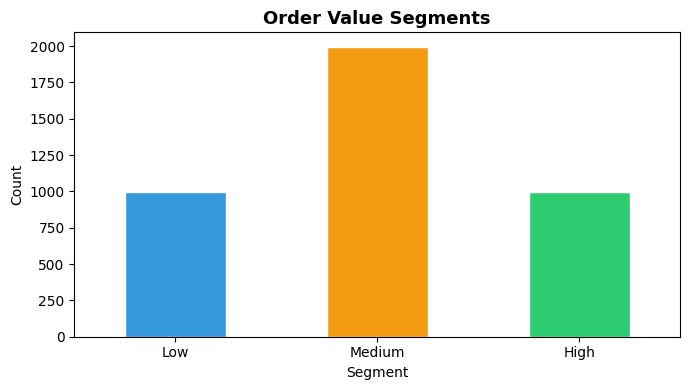

In [51]:
df = df.copy()
q1 = df['Final_Revenue'].quantile(0.25)
q3 = df['Final_Revenue'].quantile(0.75)

def segment(val):
    if val <= q1:
        return 'Low'
    elif val <= q3:
        return 'Medium'
    else:
        return 'High'

df['Order_Segment'] = df['Final_Revenue'].apply(segment)

print("Order Segment Distribution:")
print(df['Order_Segment'].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
df['Order_Segment'].value_counts().reindex(['Low', 'Medium', 'High']).plot(
    kind='bar', ax=ax, color=['#3498db', '#f39c12', '#2ecc71'], edgecolor='white'
)
ax.set_title('Order Value Segments', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Segment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Category wise Revenue Analysis

================== CATEGORY-WISE REVENUE ==================
             Total Revenue    Avg Revenue  Order Count
Category                                              
Electronics   4.538060e+08  321392.323396         1412
Furniture     4.487556e+08  342039.334818         1312
Accessories   4.135351e+08  326389.180056         1267


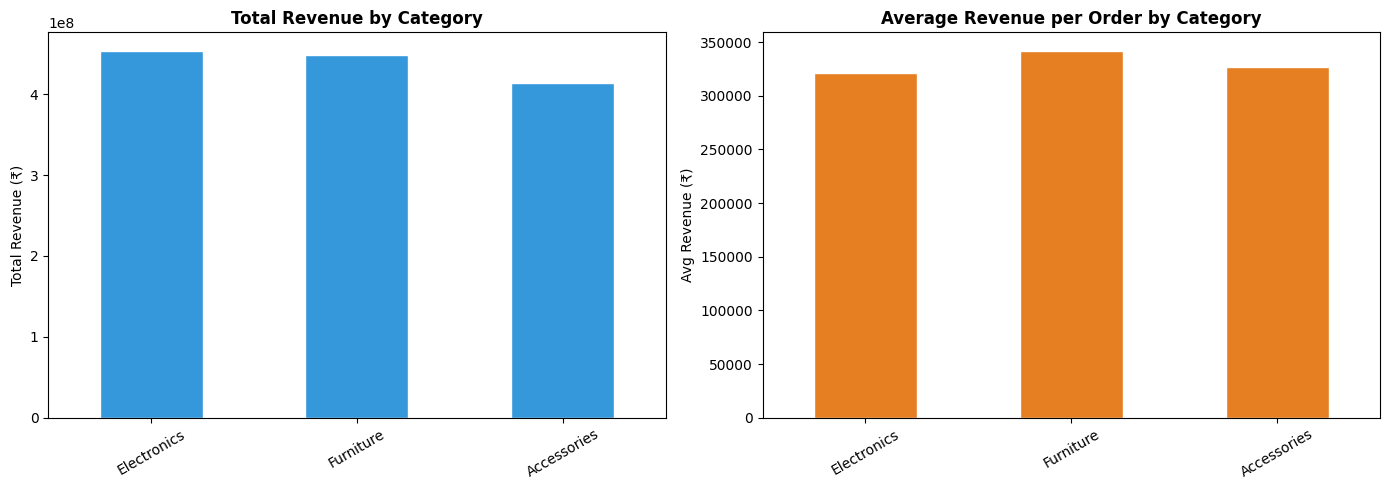

In [54]:
category_revenue = df.groupby('Category')['Final_Revenue'].agg(['sum', 'mean', 'count'])
category_revenue.columns = ['Total Revenue', 'Avg Revenue', 'Order Count']
category_revenue = category_revenue.sort_values('Total Revenue', ascending=False)

print("================== CATEGORY-WISE REVENUE ==================")
print(category_revenue.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

category_revenue['Total Revenue'].plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Total Revenue by Category', fontweight='bold')
axes[0].set_ylabel('Total Revenue (₹)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

category_revenue['Avg Revenue'].plot(kind='bar', ax=axes[1], color='#e67e22', edgecolor='white')
axes[1].set_title('Average Revenue per Order by Category', fontweight='bold')
axes[1].set_ylabel('Avg Revenue (₹)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### Region wise Revenue Analysis

================= REGION-WISE REVENUE =====================
        Total Revenue    Avg Revenue  Order Count
Region                                           
North    5.620220e+08  321522.866165         1748
South    3.849086e+08  340627.119966         1130
West     1.928200e+08  334176.742367          577
East     1.763461e+08  329003.849034          536


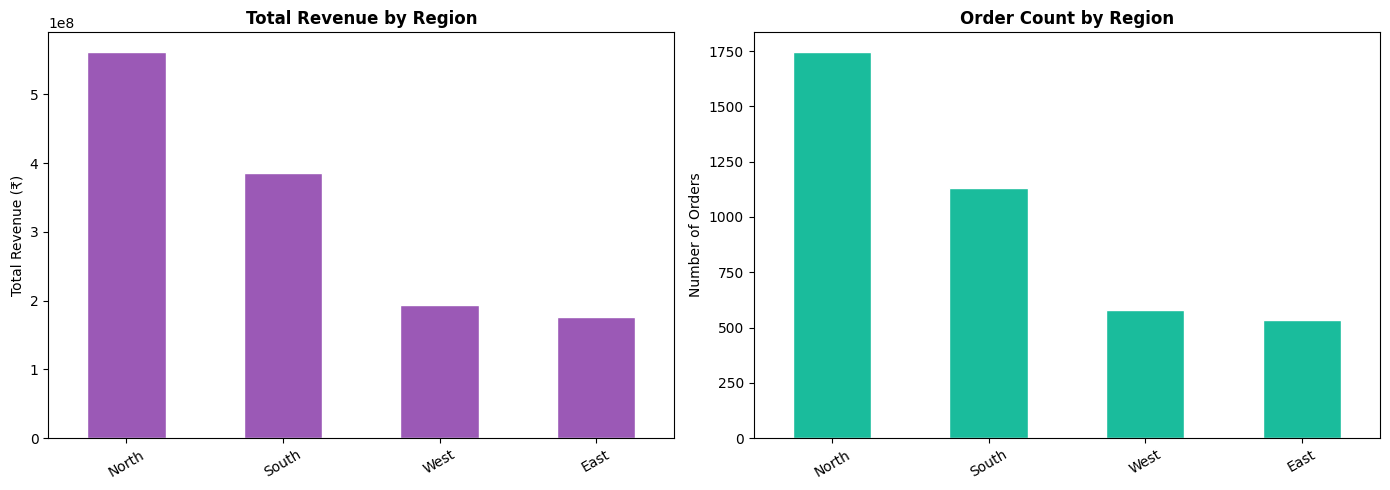

In [56]:
region_revenue = df.groupby('Region')['Final_Revenue'].agg(['sum', 'mean', 'count'])
region_revenue.columns = ['Total Revenue', 'Avg Revenue', 'Order Count']
region_revenue = region_revenue.sort_values('Total Revenue', ascending=False)

print("================= REGION-WISE REVENUE =====================")
print(region_revenue.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_revenue['Total Revenue'].plot(kind='bar', ax=axes[0], color='#9b59b6', edgecolor='white')
axes[0].set_title('Total Revenue by Region', fontweight='bold')
axes[0].set_ylabel('Total Revenue (₹)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

region_revenue['Order Count'].plot(kind='bar', ax=axes[1], color='#1abc9c', edgecolor='white')
axes[1].set_title('Order Count by Region', fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### Outlier Detection - IQR & Z-Score

============ IQR METHOD - Final_Revenue ============
Q1: 91,924.69  |  Q3: 499,801.23  |  IQR: 407,876.53
Lower fence: -519,890.10  |  Upper fence: 1,111,616.02
Outliers detected: 59 (1.5%)

======== Z-SCORE METHOD — Price ========
Outliers (|Z| > 3): 0 (0.0%)


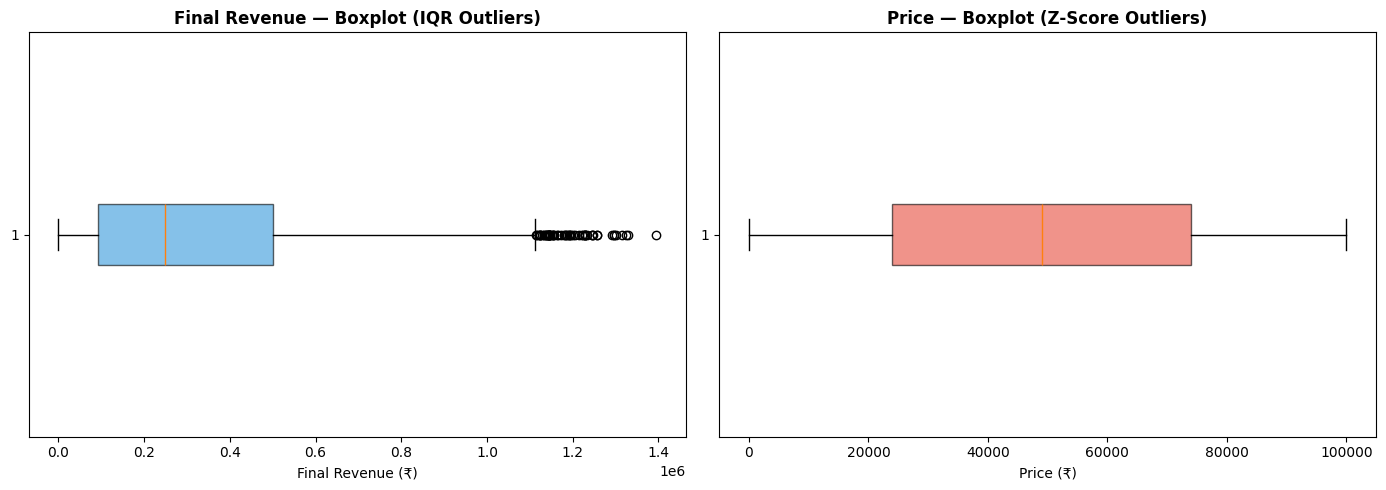


=== IMPACT OF OUTLIERS ===
IQR outliers in Final_Revenue inflate total revenue aggregations and
distort mean-based segmentation thresholds. They can cause ML models
to overfit on extreme values if not treated.

Z-score outliers in Price (extreme prices) skew the Revenue feature
since Revenue = Price x Quantity. These should be flagged and reviewed
before model training.



In [63]:
# IQR Method on Final_Revenue
Q1 = df['Final_Revenue'].quantile(0.25)
Q3 = df['Final_Revenue'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outliers = df[(df['Final_Revenue'] < lower) | (df['Final_Revenue'] > upper)]

print(f"============ IQR METHOD - Final_Revenue ============"
)
print(f"Q1: {Q1:,.2f}  |  Q3: {Q3:,.2f}  |  IQR: {IQR:,.2f}")
print(f"Lower fence: {lower:,.2f}  |  Upper fence: {upper:,.2f}")
print(f"Outliers detected: {len(iqr_outliers)} ({len(iqr_outliers)/len(df)*100:.1f}%)")

# Z-Score Method on Price
df['Price_Zscore'] = np.abs(stats.zscore(df['Price']))
zscore_outliers = df[df['Price_Zscore'] > 3]

print(f"\n======== Z-SCORE METHOD — Price ========")
print(f"Outliers (|Z| > 3): {len(zscore_outliers)} ({len(zscore_outliers)/len(df)*100:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['Final_Revenue'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[0].set_title('Final Revenue — Boxplot (IQR Outliers)', fontweight='bold')
axes[0].set_xlabel('Final Revenue (₹)')

axes[1].boxplot(df['Price'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#e74c3c', alpha=0.6))
axes[1].set_title('Price — Boxplot (Z-Score Outliers)', fontweight='bold')
axes[1].set_xlabel('Price (₹)')

plt.tight_layout()
plt.show()
impact_msg = """
=== IMPACT OF OUTLIERS ===
IQR outliers in Final_Revenue inflate total revenue aggregations and
distort mean-based segmentation thresholds. They can cause ML models
to overfit on extreme values if not treated.

Z-score outliers in Price (extreme prices) skew the Revenue feature
since Revenue = Price x Quantity. These should be flagged and reviewed
before model training.
"""
print(impact_msg)

# Drop helper column
df.drop(columns=['Price_Zscore'], inplace=True)


### Correlation Analysis

=== CORRELATION MATRIX ===
                 Price  Quantity  Discount  Customer_Rating  Revenue  Final_Revenue
Price            1.000    -0.008     0.010            0.013    0.689          0.686
Quantity        -0.008     1.000    -0.008           -0.004    0.620          0.617
Discount         0.010    -0.008     1.000           -0.008    0.000         -0.074
Customer_Rating  0.013    -0.004    -0.008            1.000    0.001          0.001
Revenue          0.689     0.620     0.000            0.001    1.000          0.995
Final_Revenue    0.686     0.617    -0.074            0.001    0.995          1.000


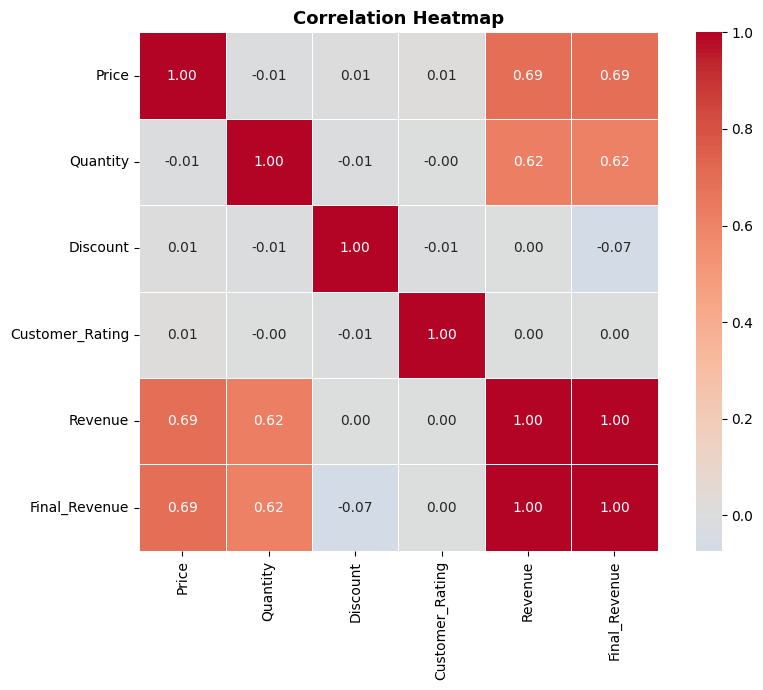


=== KEY CORRELATIONS ===

1. Price <-> Revenue (strong positive ~1.0):
   Higher priced items directly drive revenue. Price is the dominant
   factor — not quantity. The business should focus on premium product
   mix to grow revenue.

2. Discount <-> Final_Revenue (negative):
   Increasing discount reduces final revenue. Deep discounting hurts
   margins and is not offset by volume gains in this dataset.



In [64]:
numeric_cols = df[['Price', 'Quantity', 'Discount', 'Customer_Rating', 'Revenue', 'Final_Revenue']]
corr_matrix = numeric_cols.corr()

print("=== CORRELATION MATRIX ===")
print(corr_matrix.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

corr_msg = """
=== KEY CORRELATIONS ===

1. Price <-> Revenue (strong positive ~1.0):
   Higher priced items directly drive revenue. Price is the dominant
   factor — not quantity. The business should focus on premium product
   mix to grow revenue.

2. Discount <-> Final_Revenue (negative):
   Increasing discount reduces final revenue. Deep discounting hurts
   margins and is not offset by volume gains in this dataset.
"""
print(corr_msg)

# Business Insights

In [65]:
# Highest Revenue Category
top_category = df.groupby('Category')['Final_Revenue'].sum().idxmax()
top_category_val = df.groupby('Category')['Final_Revenue'].sum().max()
print(f"Highest Revenue Category: {top_category}  |  Total: ₹{top_category_val:,.2f}")

# Lowest Performing Region
bottom_region = df.groupby('Region')['Final_Revenue'].sum().idxmin()
bottom_region_val = df.groupby('Region')['Final_Revenue'].sum().min()
print(f"Lowest Performing Region: {bottom_region}  |  Total: ₹{bottom_region_val:,.2f}")

# Trend 1: Revenue by Segment
print("\n=== TREND 1 - Revenue concentration in High segment ===")
segment_rev = df.groupby('Order_Segment')['Final_Revenue'].sum()
print(segment_rev)

# Trend 2: Payment Mode preference
print("\n=== TREND 2 - Payment Mode Distribution ===")
print(df['Payment_Mode'].value_counts())

Highest Revenue Category: Electronics  |  Total: ₹453,805,960.63
Lowest Performing Region: East  |  Total: ₹176,346,063.08

=== TREND 1 — Revenue concentration in High segment ===
Order_Segment
High      7.473573e+08
Low       4.469711e+07
Medium    5.240423e+08
Name: Final_Revenue, dtype: float64

=== TREND 2 — Payment Mode Distribution ===
Payment_Mode
UPI            2031
Credit Card     679
Cash            655
Debit Card      626
Name: count, dtype: int64


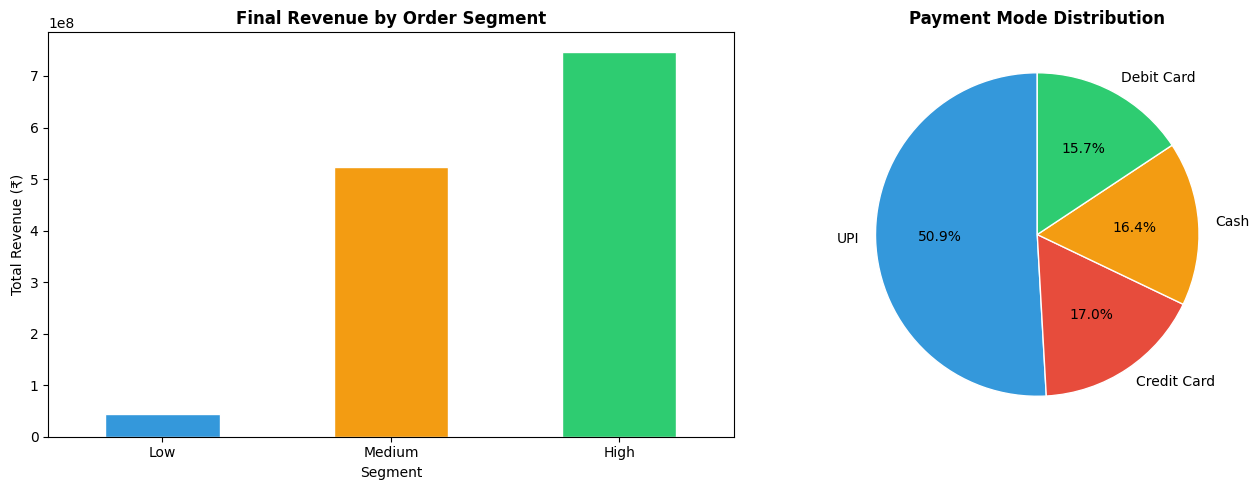

In [66]:
# Visualize both trends
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trend 1 - Revenue by Segment
df.groupby('Order_Segment')['Final_Revenue'].sum().reindex(
    ['Low', 'Medium', 'High']
).plot(kind='bar', ax=axes[0], color=['#3498db', '#f39c12', '#2ecc71'], edgecolor='white')
axes[0].set_title('Final Revenue by Order Segment', fontweight='bold')
axes[0].set_ylabel('Total Revenue (₹)')
axes[0].set_xlabel('Segment')
axes[0].tick_params(axis='x', rotation=0)

# Trend 2 - Payment Mode
df['Payment_Mode'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#3498db', '#e74c3c', '#f39c12', '#2ecc71'],
    startangle=90, wedgeprops=dict(edgecolor='white')
)
axes[1].set_title('Payment Mode Distribution', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()